In [31]:
import torch
import torch.nn as nn
import torchvision.models as models
from PIL import Image
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from torchvision import transforms
import pandas as pd
import os
from torch.utils.data import DataLoader
import torch.optim as optim
from torchvision.utils import make_grid
import torch.nn.functional as F


In [3]:
images = []
folder_path = 'video_anomaly_detection_frames/20251214_140311'
file_iter = 0
for filename in os.listdir(folder_path):
    file_iter += 1
    if(file_iter % 4 == 0):
        if filename.lower().endswith('.jpg'):
            img_path = os.path.join(folder_path, filename)
    
            with Image.open(img_path) as img:
                width, height = img.size
                cropped_img = img.crop((100, 100, width, height))
                images.append(cropped_img)

In [4]:
class ImageDataset(torch.utils.data.Dataset):
    def __init__(self, images, transform=None):
        self.images = images
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        return img


In [5]:
len(images)

387

In [6]:
transform = transforms.Compose([
    transforms.Resize((544, 960)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

dataset = ImageDataset(images, transform)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [54]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.pool = nn.AdaptiveAvgPool2d((8, 8))
        self.fc = nn.Linear(512 * 8 * 8, latent_dim)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = x.flatten(1)
        return self.fc(x)

In [55]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 34 * 60)

        self.net = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, output_padding=(0,0)),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 512, 34, 60)
        x = self.net(x)
        return x


In [58]:
class Discriminator(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.fc_z = nn.Linear(latent_dim, 256)

        self.fc_joint = nn.Linear(512, 1)

    def forward(self, x, z):
        x_feat = self.conv(x).flatten(1)
        z_feat = self.fc_z(z)
        joint = torch.cat([x_feat, z_feat], dim=1)
        return self.fc_joint(joint)


In [36]:
def denormalize(x):
    return (x + 1) / 2

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [69]:
encoder = Encoder().to(device)
decoder = Decoder().to(device)
discriminator = Discriminator().to(device)


In [70]:
recon_loss = nn.L1Loss()
adv_loss = nn.BCEWithLogitsLoss()

optim_G = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr = 2e-4)

optim_D = optim.Adam(discriminator.parameters(), lr = 1e-4)

In [79]:
w_recon = 10.0

for epoch in range(1, 51):
    for imgs in loader:
        imgs = imgs.to(device)
        batch_size = imgs.size(0)

        valid = torch.full((batch_size, 1), 0.9, device=device)
        fake = torch.zeros(batch_size, 1, device=device)

        z_real = encoder(imgs)
        z_fake = torch.randn(batch_size, z_real.size(1), device=device)
        fake_imgs = decoder(z_fake)

        imgs_noisy = imgs + 0.05 * torch.randn_like(imgs)
        fake_imgs_noisy = fake_imgs + 0.05 * torch.randn_like(fake_imgs)

        d_real = discriminator(imgs_noisy, z_real)
        d_fake = discriminator(fake_imgs_noisy.detach(), z_fake)

        d_loss = adv_loss(d_real, valid) + adv_loss(d_fake, fake)

        optim_D.zero_grad()
        d_loss.backward()

        torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 5.0)
        optim_D.step()

        z_real = encoder(imgs)
        recon = decoder(z_real)

        g_adv = adv_loss(discriminator(imgs, z_real), fake) + \
                adv_loss(discriminator(recon, z_real), valid)

        g_recon = recon_loss(recon, imgs)

        g_loss = w_recon * g_recon + g_adv * 0.3

        optim_G.zero_grad()
        g_loss.backward()
        torch.nn.utils.clip_grad_norm_(list(encoder.parameters()) + list(decoder.parameters()), 5.0)
        optim_G.step()

    print(f"Epoch {epoch:03d} | "f"G: {g_loss.item():.3f} | "f"D: {d_loss.item():.3f}")

    if epoch % 5 == 0:
        with torch.no_grad():
            idx = torch.randint(0, batch_size, (2,))
            orig_imgs = imgs[idx].cpu()
            recon_imgs = recon[idx].cpu()

            orig_imgs = denormalize(orig_imgs)
            recon_imgs = denormalize(recon_imgs)

            combined = torch.cat([orig_imgs, recon_imgs], dim=0)
            grid = make_grid(combined, nrow=2)

            plt.figure(figsize=(6, 4))
            plt.imshow(grid.permute(1, 2, 0))
            plt.axis("off")
            plt.title(f"Epoch {epoch}: Top=Original, Bottom=Reconstruction")
            plt.show()

Epoch 001 | G: 1.921 | D: 0.538
Epoch 002 | G: 1.691 | D: 0.550
Epoch 003 | G: 1.741 | D: 0.486
Epoch 004 | G: 1.373 | D: 0.505


KeyboardInterrupt: 

In [82]:
encoder.eval()
embeddings = []

with torch.no_grad():
    for imgs in loader:
        imgs = imgs.to(device)
        z = encoder(imgs)
        embeddings.append(z.cpu())

embeddings = torch.cat(embeddings).numpy()


In [76]:
from sklearn.manifold import TSNE

In [ ]:
def blurred_l1(img, recon, kernel_size=11):
    pad = kernel_size // 2
    img_blur = F.avg_pool2d(img, kernel_size, stride=1, padding=pad)
    recon_blur = F.avg_pool2d(recon, kernel_size, stride=1, padding=pad)
    return torch.mean(torch.abs(img_blur - recon_blur), dim=(1,2,3))

In [112]:
def anomaly_score_batch(imgs):
    with torch.no_grad():
        z = encoder(imgs)
        recon = decoder(z)
        scores = blurred_l1(imgs, recon)
    return scores.detach().cpu().numpy()

In [113]:
def compute_scores(dataset, batch_size=16):
    scores = []
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

    for imgs in loader:
        imgs = imgs.to(device, non_blocking=True)
        batch_scores = anomaly_score_batch(imgs)
        scores.append(batch_scores)

    return np.concatenate(scores)


In [114]:
def visualize_embeddings_anomaly(embeddings, scores):
    embeddings = np.asarray(embeddings)
    scores = np.asarray(scores)

    tsne = TSNE(n_components=2, perplexity=30, init="pca")
    emb_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        emb_2d[:, 0],
        emb_2d[:, 1],
        c=scores,
        cmap='hot',
        s=20
    )
    plt.colorbar(scatter, label='Anomaly Score')
    plt.title("t-SNE of Embeddings Colored by Anomaly Score")
    plt.tight_layout()
    plt.show()


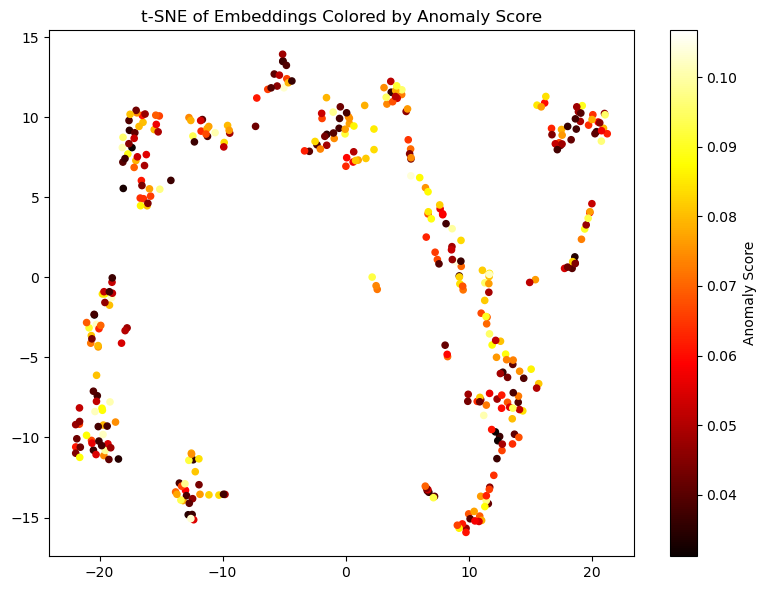

In [115]:
scores = compute_scores(dataset, batch_size=16)
visualize_embeddings_anomaly(embeddings, scores)


In [111]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [90]:
import torch

encoder.eval()
all_z = []
all_imgs = []

with torch.no_grad():
    for imgs in loader:
        imgs = imgs.to(device)
        z = encoder(imgs) 
        all_z.append(z.cpu())
        all_imgs.append(imgs.cpu())

all_z = torch.cat(all_z, dim=0).numpy()
all_imgs = torch.cat(all_imgs, dim=0)


In [121]:
from sklearn.cluster import DBSCAN
import numpy as np

eps = 0.27
dbscan = DBSCAN(eps=eps, min_samples=2)
clusters = dbscan.fit_predict(all_z)

anomaly_mask = clusters == -1
normal_mask = clusters != -1

print(f"Total samples: {len(all_z)}")
print(f"Anomalies detected: {np.sum(anomaly_mask)}")

Total samples: 387
Anomalies detected: 21


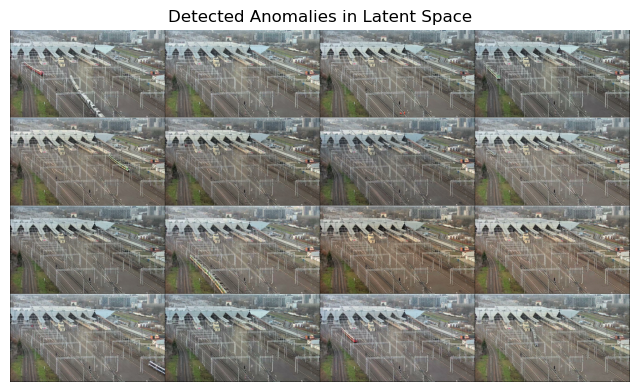

In [123]:
N = 16
anomaly_imgs = all_imgs[anomaly_mask][:N]

anomaly_imgs = denormalize(anomaly_imgs)

grid = make_grid(anomaly_imgs, nrow=4)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Detected Anomalies in Latent Space")
plt.show()


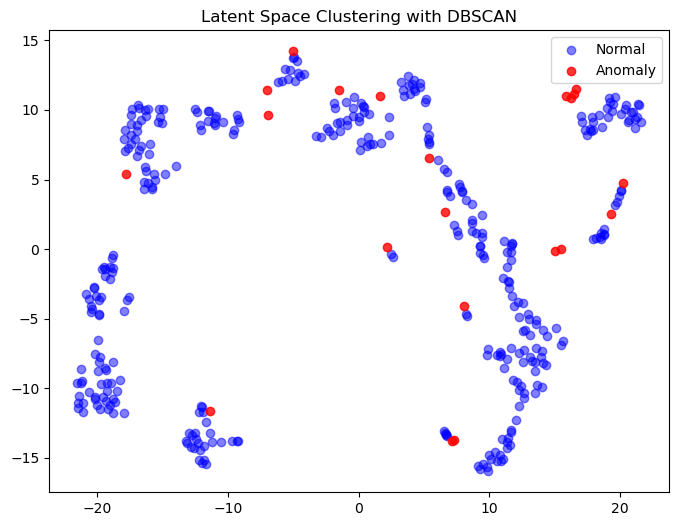

In [122]:
from sklearn.manifold import TSNE

z_2d = TSNE(n_components=2, random_state=42).fit_transform(all_z)

plt.figure(figsize=(8, 6))
plt.scatter(z_2d[normal_mask, 0], z_2d[normal_mask, 1], c='blue', label='Normal', alpha=0.5)
plt.scatter(z_2d[anomaly_mask, 0], z_2d[anomaly_mask, 1], c='red', label='Anomaly', alpha=0.8)
plt.legend()
plt.title("Latent Space Clustering with DBSCAN")
plt.show()


In [45]:
import heapq

In [44]:
def show_top_anomalies(encoder, decoder, dataset, device, top_k=10, batch_size=4):
    encoder.eval()
    decoder.eval()

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    top_scores = []

    with torch.no_grad():
        for batch_idx, imgs in enumerate(loader):
            imgs = imgs.to(device)
            recon = decoder(encoder(imgs))
            scores = blurred_l1(imgs, recon)

            for i in range(len(imgs)):
                item = (scores[i].item(),imgs[i].cpu(),recon[i].cpu())
                if len(top_scores) < top_k:
                    heapq.heappush(top_scores, item)
                else:
                    heapq.heappushpop(top_scores, item)

    top_scores = sorted(top_scores, key=lambda x: x[0], reverse=True)

    fig, axes = plt.subplots(top_k, 3, figsize=(10, 3 * top_k))

    for i, (score, img, recon) in enumerate(top_scores):
        img = denormalize(img.permute(1, 2, 0)).clamp(0,1)
        recon = denormalize(recon.permute(1, 2, 0)).clamp(0,1)
        diff = torch.abs(img - recon)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Original")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(recon)
        axes[i, 1].set_title("Reconstruction")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(diff)
        axes[i, 2].set_title(f"Diff | Score={score:.4f}")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()
    plt.close(fig)

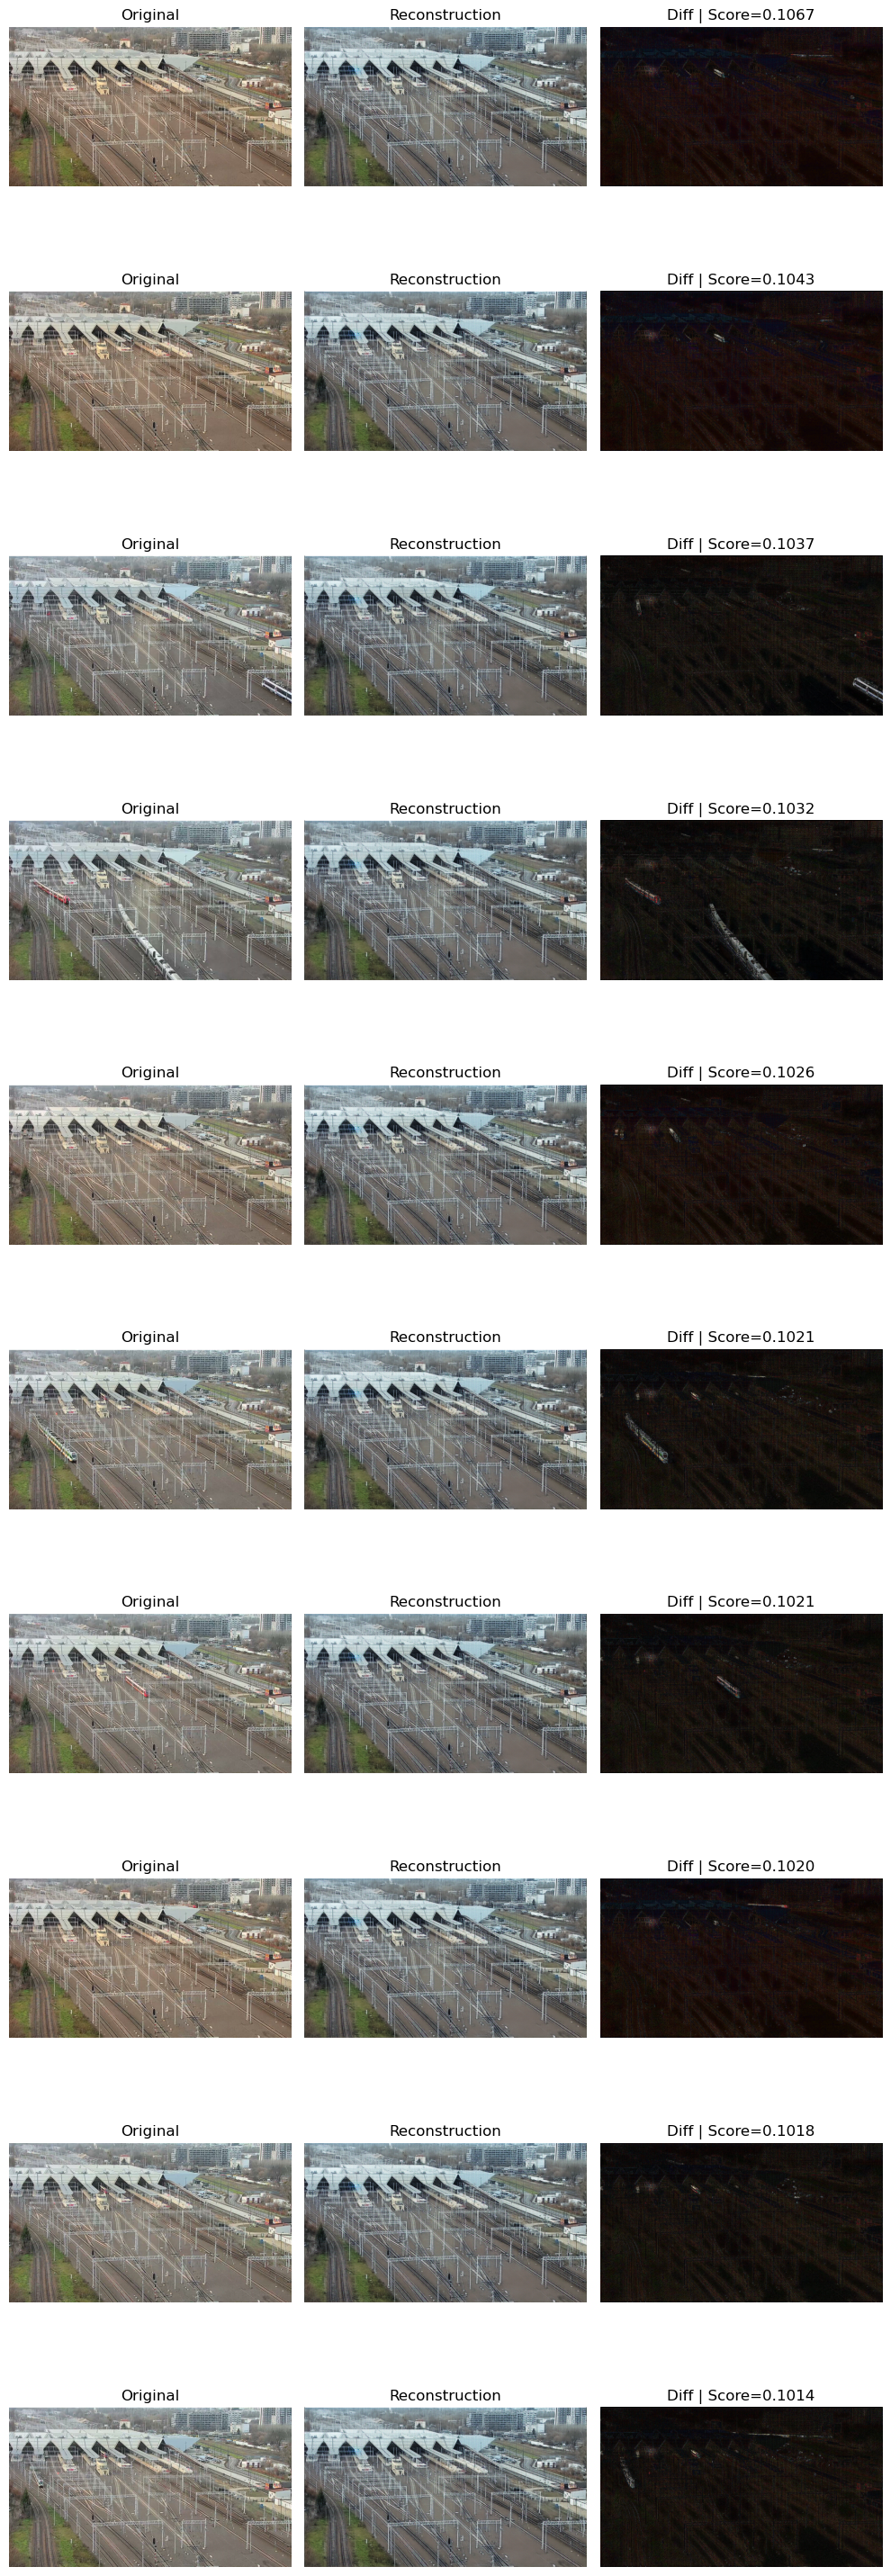

In [80]:
show_top_anomalies(encoder,decoder,dataset,device,top_k=10)